# "Йети": классификация пользователей на возрастные сегменты.

### Задача

Заказчик проекта — крупная IT-компания «Йети», которая управляет группой популярных интернет-сервисов. Каждый день через них проходят миллионы пользователей. Значительную часть дохода компания получает от контекстной рекламы, то есть от объявлений на страницах своих сайтов.

Алгоритмы рекламной сети «Йети» (РСЙ) используют демографический таргетинг, включая возрастной. Они собирают данные через технологию, анализирующую поведение пользователей без прямого доступа к их паспортным данным. Задача — создать инструмент, который будет автоматически определять возрастную категорию пользователей.

Нужна модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст. Это позволит показывать товар тем, кому он действительно нужен. Результат модели станет основой для реализации замыслов маркетологов о том, чтобы показывать рекламу на целевую аудиторию определённого возраста и снизить риски показа рекламы для взрослых несовершеннолетним.

Источником информации для модели будут логи посещений сайтов. Там указано, какие категории сайтов посещали пользователи, как часто и в какое время.

### Цель

Целью проекта является создание модели машинного обучения для многоклассовой классификации пользователей интернет-сервисов на возрастные сегменты. Основной метрикой качества послужит F1-мера, которая должна составить не менее 0.75 (75%) для рекомендации модели к внедрению. Дополнительными метриками качества будут precision и recall.

### Описание данных

#### **Таблица `users`**

Таблица [ds_s13_users.csv](https://code.s3.yandex.net/datasets/ds_s13_users.csv) содержит информацию о возрастной категории пользователя:

- `user_id` — уникальный идентификатор пользователя.
- `age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать. Содержит следующие категории:
    - `0`: младше 18;
    - `1`: 18-25 лет;
    - `2`: 26-40 лет;
    - `3`: 41-55 лет;
    - `4`: 56+ лет.

#### **Таблица `visits`**

Лог посещений сайтов [ds_s13_visits.csv](https://code.s3.yandex.net/datasets/ds_s13_visits.csv) похож на данные сервиса веб-аналитики [«Яндекс Метрика»](https://yandex.ru/adv/metrika). Он предназначен для сбора и анализа информации об активности пользователей разных сайтов. Заказчик попросил в целях защиты персональных данных заменить в логах все URL на анонимизированную категорию сайта, а вместо точного времени использовать время суток.

Признаки в датасете:

- `date` — дата посещения сайта.
- `daytime` — анонимизированное время посещения сайта. Категории: `утро`, `день`, `вечер`, `ночь`.
- `session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
- `user_id` — уникальный идентификатор пользователя.
- `website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

#### **Таблица `ads_activity`**

Активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом. Информация об этом признаке представлена в таблице [ads_activity.csv](https://code.s3.yandex.net/datasets/ads_activity.csv):

- `user_id` — уникальный идентификатор пользователя.
- `ads_activity` — характеристика CTR, выраженная одним из значений: `очень редко`, `редко`, `умеренно`, `часто`, `очень часто`.

Напомним: CTR (Click-Through Rate) — термин в интернет-маркетинге, показатель кликабельности. Показывает, как часто люди кликают по объявлению с рекламой, ссылке в поисковой выдаче или кнопке.

#### **Таблица `surf_depth`**

В таблице [surf_depth.csv](https://code.s3.yandex.net/datasets/surf_depth.csv) содержится два признака:

- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории `поверхностно`, `средне`, `глубоко`.

#### **Таблица `primary_device`**

Таблица [primary_device.csv](https://code.s3.yandex.net/datasets/primary_device.csv) содержит два признака:

- `user_id` — уникальный идентификатор пользователя.
- `primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

Такие данные о пользователях можно взять на сервисах типа [Крипты](https://yandex.ru/support/direct/ru/technologies-and-services/crypta). Каждое устройство и браузер, которым человек пользуется для выхода в интернет, имеет свой уникальный идентификатор. Крипта умеет определять, что все эти идентификаторы принадлежат одному пользователю, по схожести его поведения на разных устройствах или по более точным факторам: например, по использованию одного и того же логина. Также учитывается, что одним устройством могут пользоваться сразу несколько человек: члены семьи или коллеги. Так Крипта составляет более полный портрет пользователя.

#### **Таблица `cloud_usage`**

Использование облачных технологий описано в файле [cloud_usage.csv](https://code.s3.yandex.net/datasets/cloud_usage.csv):

- `user_id` — уникальный идентификатор пользователя;
- `cloud_usage` — `True` означает, что пользователь обращается к [облачным](https://practicum.yandex.ru/blog/oblachnye-tehnologii/) ресурсам типа [Яндекс 360](https://360.yandex.ru/) прямо или через посещаемые сайты.

### Этапы выполнения

- Подготовка среды и библиотек: установка и импорт необходимых библиотек, настройка визуального представления графиков.
- Исследовательский анализ данных (EDA): ознакомление с данными, изучение дубликатов, пропусков, категориальных и числовых признаков, проверка корреляций. 
- Предобработка данных: создание пайплайна предобработки, включающего нормализацию, кодирование, заполнение пропусков.
- Обучение и оценка базовой модели: обучение DummyClassifier и базовой LogisticRegression.
- Создание и отбор признаков: инжинириг и отбор самых полезных признаков.
- Подбор гиперпараметров моделей
- Подготовка артефактов модели для внедрения.
- Выводы о результатах работы.

## Подготовка среды и библиотек

### Установка и импорт библиотек, создание requirements.txt

In [1]:
!pip install phik -q

In [2]:
!pip install category_encoders -q

In [3]:
!pip install scipy==1.9.1 --user -q
!pip install seaborn==0.11.1 --user -q

In [4]:
import pandas as pd
import numpy as np

from functools import reduce

import sys

import phik

#import warnings
#warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier 

from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_validate, 
    GridSearchCV,
    GroupShuffleSplit
)

from sklearn.feature_selection import RFE, VarianceThreshold, RFECV, SelectFromModel
from sklearn.feature_selection import SequentialFeatureSelector as SFS

from sklearn.metrics import (
    average_precision_score,
    log_loss,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

from sklearn.base import clone, BaseEstimator, TransformerMixin

from scipy.special import expit

import joblib
import json
import sklearn

from pathlib import Path
import math

In [5]:
!pip freeze > requirements_yeti.txt

### Настройка отображения графиков и визуализаций, фиксирование переменных

In [6]:
sns.set_theme(
    style="whitegrid",       # Options: 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'
    context="notebook",      # Options: 'paper', 'notebook', 'talk', 'poster' (scales text/lines)
    palette="deep",          # Options: 'deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind'
)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

In [7]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

### Загрузка данных и формирование общего датасета

In [8]:
df1 = pd.read_csv('datasets/ds_s13_users.csv')
df2 = pd.read_csv('datasets/ds_s13_visits.csv', sep=',', decimal='.')
df3 = pd.read_csv('datasets/ads_activity.csv')
df4 = pd.read_csv('datasets/primary_device.csv') 
df5 = pd.read_csv('datasets/surf_depth.csv')
df6 = pd.read_csv('datasets/cloud_usage.csv')

datasets = [df1, df2, df3, df4, df5, df6]

In [9]:
for df in datasets:
    display(df.head(5))

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


In [10]:
def df_creation(datasets, on, how):
    df = reduce(lambda left, right: pd.merge(left, right, on=on, how=how), datasets)
    return df


In [11]:
df = df_creation(datasets, 'user_id', 'left')

In [12]:
df.head()

,user_id,age_category,date,daytime,session_id,website_category,ads_activity,primary_device,surf_depth,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-01,вечер,129666ac-5f51-4726-9eff-c08a938cf148,Category 01,NaN,смартфон,глубоко,False
1,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-01,вечер,1ac4ebdb-de6f-46ce-9a76-002f7ec07702,Category 18,NaN,смартфон,глубоко,False
2,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-01,вечер,29733517-83d1-4dbc-a63f-95ab97f0c806,Category 16,NaN,смартфон,глубоко,False
3,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-01,вечер,3c37b52d-12ef-4152-b0de-c72eb5db9359,Category 14,NaN,смартфон,глубоко,False
4,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-01,вечер,e8aff21f-d45e-4bac-9745-ae8c6372dfa7,Category 15,NaN,смартфон,глубоко,False


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1123383 entries, 0 to 1123382
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   user_id           1123383 non-null  object
 1   age_category      1123383 non-null  int64 
 2   date              1123383 non-null  object
 3   daytime           1123383 non-null  object
 4   session_id        1123383 non-null  object
 5   website_category  1123383 non-null  object
 6   ads_activity      1081281 non-null  object
 7   primary_device    1093007 non-null  object
 8   surf_depth        1100610 non-null  object
 9   cloud_usage       1097090 non-null  object
dtypes: int64(1), object(9)
memory usage: 94.3+ MB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_category,1123383.0,2.438319,1.375107,0.0,2.0,3.0,4.0,4.0


### Вывод

Библиотеки успешно импортированы. Файл requirements.txt создан. Параметры визуализаций настроены, RANDOM_STATE установлен. Загружены необходимые данные, объединенные в общий датасет df. Датасет содержит 1 123 383 записей, имеет 10 столбцов. Видно, что большинство признаков являются категориальными.

## Исследовательский анализ данных

### Базовая информация о датасете

In [15]:
print("Кол-во признаков:", df.shape[1])
print("Кол-во записей:", df.shape[0])

Кол-во признаков: 10
Кол-во записей: 1123383


In [16]:
df.columns

Index(['user_id', 'age_category', 'date', 'daytime', 'session_id',
       'website_category', 'ads_activity', 'primary_device', 'surf_depth',
       'cloud_usage'],
      dtype='object')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1123383 entries, 0 to 1123382
Data columns (total 10 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   user_id           1123383 non-null  object
 1   age_category      1123383 non-null  int64 
 2   date              1123383 non-null  object
 3   daytime           1123383 non-null  object
 4   session_id        1123383 non-null  object
 5   website_category  1123383 non-null  object
 6   ads_activity      1081281 non-null  object
 7   primary_device    1093007 non-null  object
 8   surf_depth        1100610 non-null  object
 9   cloud_usage       1097090 non-null  object
dtypes: int64(1), object(9)
memory usage: 94.3+ MB


Датасет содержит 1 123 383 записей, имеет 10 столбцов. Среди признаков имеется: `user_id` - уникальный идентификатор пользователя, `age_category` - возрастная категория пользователя (целевая переменная), `date` - дата (день, месяц, год), `daytime` - время суток, `session_id` - уникальный идентификатор сессии, `website_category` - категория сайта, `ads_activity` - активность взаимодействия с рекламой, `primary_device` - тип основного устройства для выхода в Интернет, `surf_depth` - глубина перехода пользователя по сайтам во время сессии, `cloud_usage` - обращается ли пользователь к облачным ресурсам. Преимущественно признаки имеют тип `object`, т.е. текстовый формат. Только целевая переменная `age_category` представлена целочисленным форматом.

### Целевая переменная

In [18]:
print(df['age_category'].value_counts(normalize=True))

4    0.299129
2    0.253901
3    0.216776
0    0.146519
1    0.083676
Name: age_category, dtype: float64


,Кол-во (логи),Доля (%)
56+,336036,29.91
26-40,285228,25.39
41-55,243522,21.68
<18,164597,14.65
18-25,94000,8.37


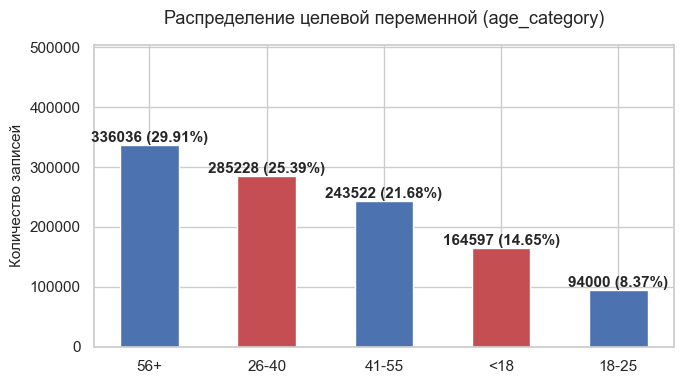

In [19]:
age_counts = df['age_category'].value_counts()
age_perc = df['age_category'].value_counts(normalize=True) * 100

age_stats = pd.DataFrame({"Кол-во (логи)": age_counts, "Доля (%)": age_perc.round(2)})

age_stats.index = age_stats.index.map({0: "<18", 1: "18-25", 2: "26-40", 3: "41-55", 4: "56+"})

display(age_stats.sort_values('Доля (%)', ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(age_stats.index, age_stats['Кол-во (логи)'], color=["#4C72B0", "#C44E52"], width=0.5)

for bar, pct in zip(bars, age_stats['Доля (%)']):
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 100,
        f"{int(yval)} ({pct}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )
    
ax.set_title("Распределение целевой переменной (age_category)", fontsize=13, pad=15)
ax.set_ylabel("Количество записей", fontsize=11)
ax.set_ylim(0, max(age_counts) * 1.5)
plt.tight_layout()
plt.show()

Распределение целевой переменной, по крайней мере по сессиям пользователей, неравномерное. Можно сказать, что большее количество сессий приходит на диапазоны 26-56+ лет (~76% от всех сессий), где у пользователей 56+ львиная доля ~30%. Молодые люди <18 лет имеют ~15% записей. Меньше всего сессий у диапазона 18-25 лет (8.37%).

### Изучение признаков

In [20]:
df_unique = df.nunique()
print(df_unique)

user_id                5826
age_category              5
date                     14
daytime                   4
session_id          1049995
website_category         20
ads_activity              5
primary_device            4
surf_depth                3
cloud_usage               2
dtype: int64


In [21]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}\n")

user_id: ['f545-8c95aefe8d3e5548a689-a5b2fd39' 'cb48-5a0d6cde4d86ae10637e-c8ceb6ed'
 '678b-614cd47d854b9d591db2-000b2e50' ...
 'e0d8-1b36a6b475ebfbf87c14-fa566d97' 'ad58-7c3c5b76a1dd90ba850d-0307d559'
 'c892-72c57d41488d7956d880-3474e42b']

age_category: [4 2 0 1 3]

date: ['2025-11-01' '2025-11-02' '2025-11-03' '2025-11-04' '2025-11-05'
 '2025-11-06' '2025-11-07' '2025-11-08' '2025-11-09' '2025-11-10'
 '2025-11-11' '2025-11-12' '2025-11-13' '2025-11-14']

daytime: ['вечер' 'день' 'утро' 'ночь']

session_id: ['129666ac-5f51-4726-9eff-c08a938cf148'
 '1ac4ebdb-de6f-46ce-9a76-002f7ec07702'
 '29733517-83d1-4dbc-a63f-95ab97f0c806' ...
 'e5f2f64a-c80c-45e1-8674-f7bbaa827592'
 '43ed9701-0289-4842-8a05-b592da9abbc4'
 'def0f845-aa9c-49d2-940e-af1166f62227']

website_category: ['Category 01' 'Category 18' 'Category 16' 'Category 14' 'Category 15'
 'Category 13' 'Category 04' 'Category 08' 'Category 19' 'Category 09'
 'Category 05' 'Category 03' 'Category 17' 'Category 02' 'Category 20'
 'Categor

In [22]:
def plot_categorical_distributions(df, max_unique=20, n_cols=2):
    cat_cols = [
        c for c in df.columns
        if df[c].nunique(dropna=True) <= max_unique
        and (
            pd.api.types.is_object_dtype(df[c])
            or isinstance(df[c].dtype, pd.CategoricalDtype)
            or pd.api.types.is_integer_dtype(df[c])
        )
    ]

    if not cat_cols:
        print("Категориальные признаки для визуализации не найдены.")
        return

    n_rows = math.ceil(len(cat_cols) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(14, min(5 * n_rows, 30)),
                             squeeze=False)
    axes = axes.ravel()

    for ax, col in zip(axes, cat_cols):
        order = df[col].value_counts(dropna=True).index
        sns.countplot(data=df, y=col, order=order, palette="viridis",
              hue=col, ax=ax)
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        total = df[col].notna().sum()
        x0, x1 = ax.get_xlim()
        offset = (x1 - x0) * 0.01
        for p in ax.patches:
            pct = f'{100 * p.get_width() / total:.1f}%'
            ax.annotate(pct,
                        (p.get_width() + offset,
                         p.get_y() + p.get_height() / 2),
                        va='center', ha='left', fontsize=10)
        ax.set_xlim(x0, x1 * 1.15)

        n_na = df[col].isna().sum()
        na_part = f", Пропусков: {n_na}" if n_na else ""
        ax.set_title(f"'{col}' (Уникальных: {df[col].nunique()}{na_part})",
                     fontsize=12, weight='bold')
        ax.set_xlabel("Количество записей")
        ax.set_ylabel("")

    for ax in axes[len(cat_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

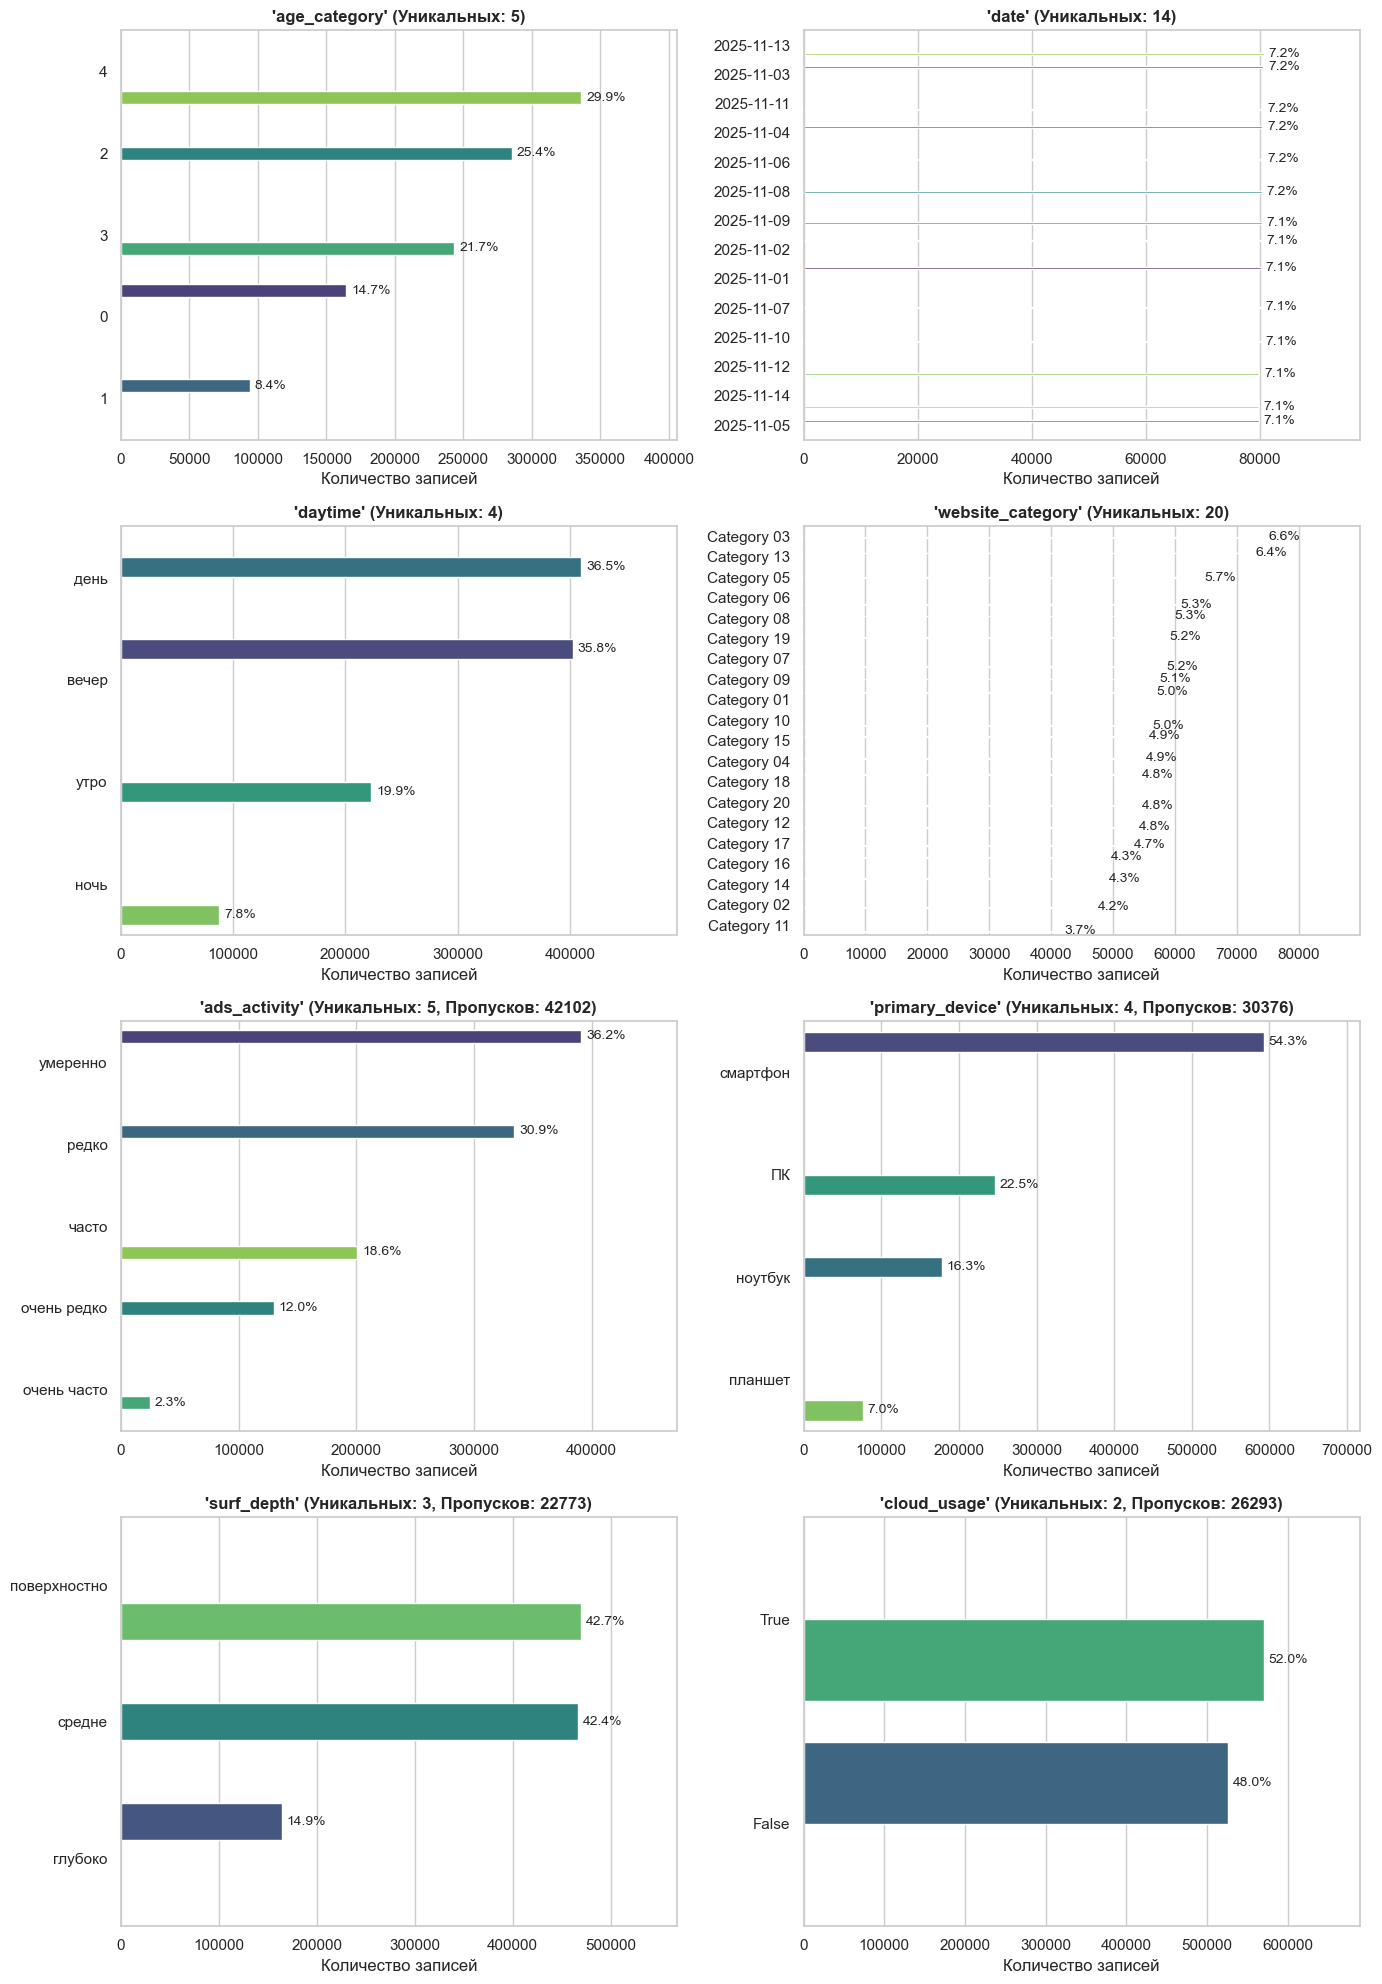

In [23]:
plot_categorical_distributions(df)

В общем датафрейме фигурирует 5826 пользователей, уникальных сессий 1 049 995.
Об остальных признаках известно следующее:
- `age_category` - 5 уникальных значений: 0, 1, 2, 3, 4.
- `date` - 14 уникальных значений: 2025-11-01 - 2025-11-14 (данные за две недели).
- `daytime` - 4 уникальных значения: утро, день, вечер, ночь.
- `website_category` - 20 уникальных значений: Category 1-20.
- `ads_activity` - 5 уникальных значений: очень редко, редко, умеренно, часто, очень часто. Имеются пропуски.
- `primary_device` - 4 уникальных значений: смартфон, планшет, ноутбук, ПК. Есть пропуски.
- `surf_depth` - 3 уникальных значения: поверхностно, средне, глубоко. Пропуски присутствуют.
- `cloud_usage` - 2 уникальных значения: True или False. Есть пропуски.

### Пропуски и дубликаты

In [24]:
missing_percentage = df.isna().mean() * 100

print(missing_percentage)

user_id             0.000000
age_category        0.000000
date                0.000000
daytime             0.000000
session_id          0.000000
website_category    0.000000
ads_activity        3.747787
primary_device      2.703975
surf_depth          2.027180
cloud_usage         2.340520
dtype: float64



=== ads_activity ===
is_na_ads_activity      0     1
age_category                   
0                   97.35  2.65
1                   97.37  2.63
2                   95.44  4.56
3                   96.19  3.81
4                   96.14  3.86


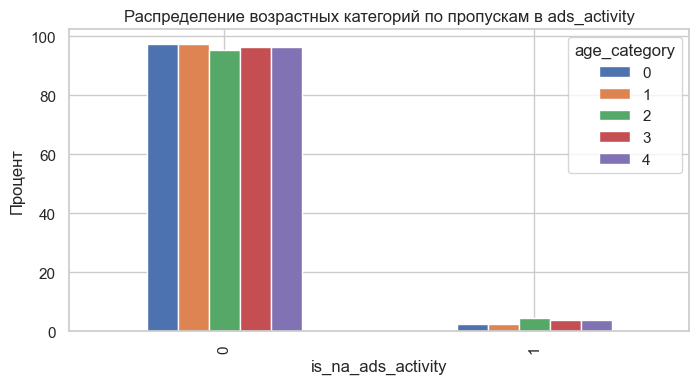


=== primary_device ===
is_na_primary_device      0     1
age_category                     
0                     96.86  3.14
1                     97.90  2.10
2                     97.30  2.70
3                     97.49  2.51
4                     97.20  2.80


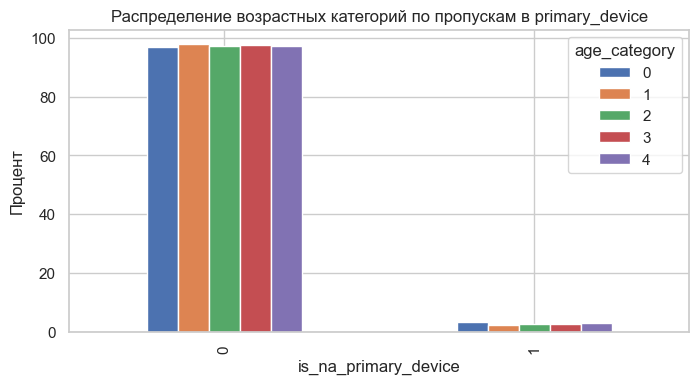


=== surf_depth ===
is_na_surf_depth      0     1
age_category                 
0                 97.51  2.49
1                 98.35  1.65
2                 97.92  2.08
3                 98.07  1.93
4                 98.07  1.93


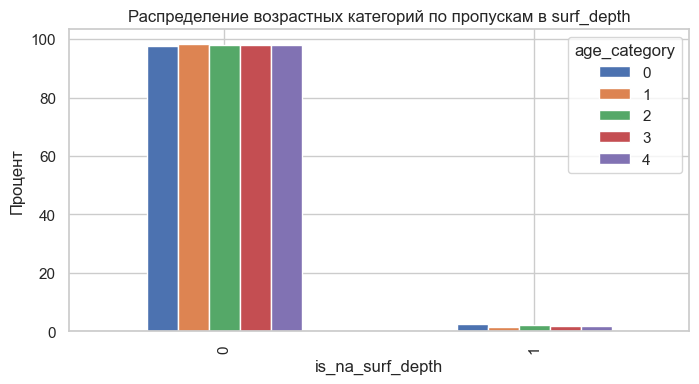


=== cloud_usage ===
is_na_cloud_usage      0     1
age_category                  
0                  98.23  1.77
1                  97.88  2.12
2                  97.45  2.55
3                  98.52  1.48
4                  96.87  3.13


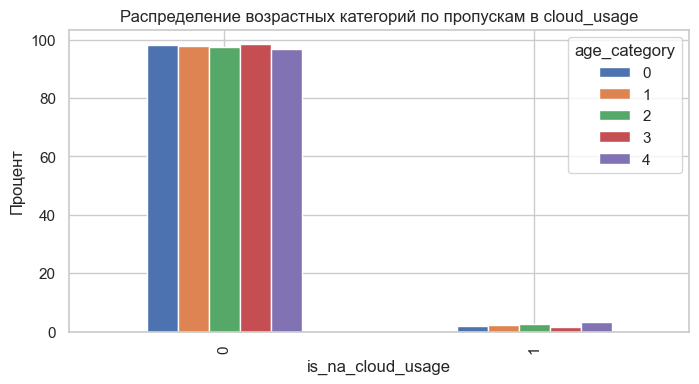

In [25]:
features_with_na = ['ads_activity', 'primary_device', 'surf_depth', 'cloud_usage']

df1 = df.copy()

for col in features_with_na:
    df1[f'is_na_{col}'] = df1[col].isnull().astype(int)
    
    pivot = pd.crosstab(df1['age_category'], df1[f'is_na_{col}'], normalize='index') * 100
    print(f"\n=== {col} ===")
    print(pivot.round(2))
    
    pivot.T.plot(kind='bar', figsize=(8,4), title=f'Распределение возрастных категорий по пропускам в {col}')
    plt.ylabel('Процент')
    plt.show()

In [26]:
duplicates = df[df.duplicated(keep=False)]
duplicates.head(10)

,user_id,age_category,date,daytime,session_id,website_category,ads_activity,primary_device,surf_depth,cloud_usage
40,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-03,утро,743524e3-33cc-4093-b856-82a044230cb7,Category 04,NaN,смартфон,глубоко,False
41,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-03,утро,743524e3-33cc-4093-b856-82a044230cb7,Category 04,NaN,смартфон,глубоко,False
110,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-08,день,c81125f8-b54c-41cb-9a06-e922d59d5161,Category 11,NaN,смартфон,глубоко,False
111,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-08,день,c81125f8-b54c-41cb-9a06-e922d59d5161,Category 11,NaN,смартфон,глубоко,False
121,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-09,ночь,5b5a744e-f29d-4929-905f-eb3b152e48f7,Category 11,NaN,смартфон,глубоко,False
122,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-09,ночь,5b5a744e-f29d-4929-905f-eb3b152e48f7,Category 11,NaN,смартфон,глубоко,False
142,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-11,вечер,a7513c2e-fdae-4cf1-ad28-cb85a9c16556,Category 05,NaN,смартфон,глубоко,False
143,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-11,вечер,a7513c2e-fdae-4cf1-ad28-cb85a9c16556,Category 05,NaN,смартфон,глубоко,False
184,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-14,день,31ba731a-c67d-4c0d-9421-c8ec4af42468,Category 01,NaN,смартфон,глубоко,False
185,f545-8c95aefe8d3e5548a689-a5b2fd39,4,2025-11-14,день,31ba731a-c67d-4c0d-9421-c8ec4af42468,Category 01,NaN,смартфон,глубоко,False


In [27]:
df_size_0 = df.shape
print(df_size_0)

(1123383, 10)


In [28]:
df = df.drop_duplicates()
df_size_1 = df.shape
print(df_size_1)

(1049995, 10)


In [29]:
print(f"Было строк: {df_size_0[0]}")
print(f"Удалено строк: {df_size_0[0] - df_size_1[0]}")
print(f"Стало строк: {df_size_1[0]}")

Было строк: 1123383
Удалено строк: 73388
Стало строк: 1049995


В признаках `ads_activity`, `primary_device`, `surf_depth`, `cloud_usage` присутствуют пропуски. Их доля составляет примерно 2.02-3.7%, что не так много. Судя по распределению пропусков признаков по возрастным категориям, вероятно, существуют определенные закономерности отсутствия данных. Например, в `ads_activity` пропуски преобладают у пользователей 26-40 лет, которые скорее всего пользуются блокировщиком рекламы. Поэтому пропуски в большинстве признаков можно заполнить сигналом `unknown`. В данном случае это не должно перегрузить модель и, вероятно, окажет положительное влияние на качество. Признак `cloud_usage`, который по сути имеет тип `bool`, стоит заполнить модой. 

В датасете обнаружены полные дубликаты записей, они были удалены (73388 строк). Теперь количество записей соответствует уникальным значениям `session_id` (1049995).

### Распределение признаков

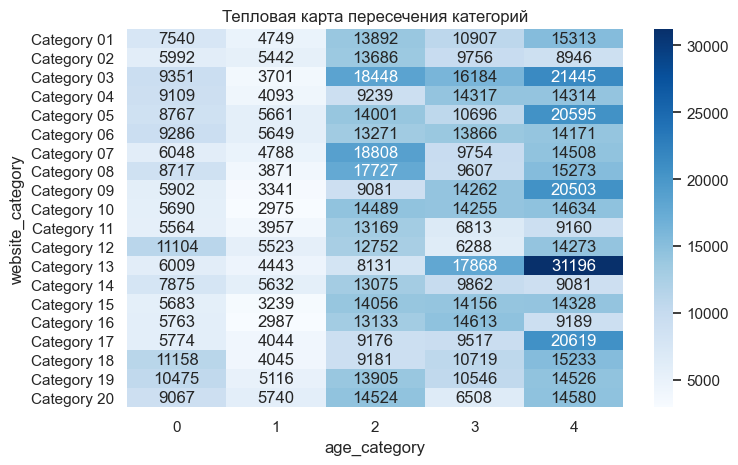

In [30]:
ct = pd.crosstab(df['website_category'], df['age_category'])

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')

plt.title('Тепловая карта пересечения категорий')
plt.show()

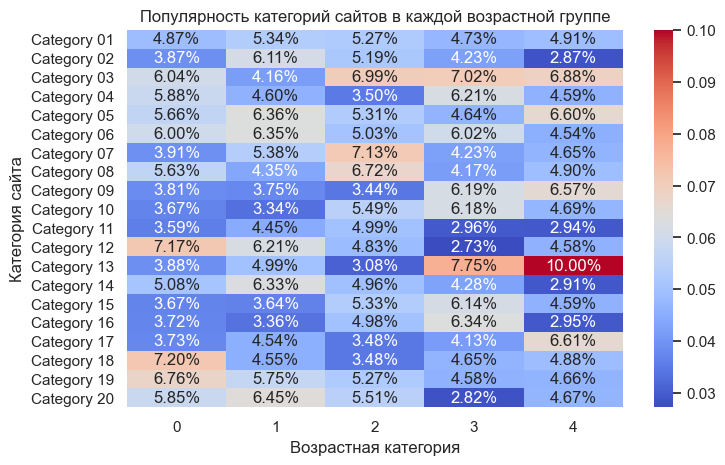

In [31]:
ct_row_norm = ct.div(ct.sum(axis=0), axis=1)
sns.heatmap(ct_row_norm, annot=True, fmt='.2%', cmap='coolwarm')

plt.title('Популярность категорий сайтов в каждой возрастной группе')
plt.xlabel('Возрастная категория', fontsize=12)
plt.ylabel('Категория сайта', fontsize=12)
plt.show()

У каждой возрастной категории наблюдаются наиболее популярные категории сайтов. Например, у пользователей с возрастом 41-56+ очень популярны сайты `Category 13`. А у пользователей меньше 18 лет в приоритете сайты `Category 18` и `Category 19`, в то же время у других возрастов эти сайты не особо популярны. Можно сделать вывод, что категория посещаемых сайтов окажется полезным признаком для предсказания возрастной категории пользователя.

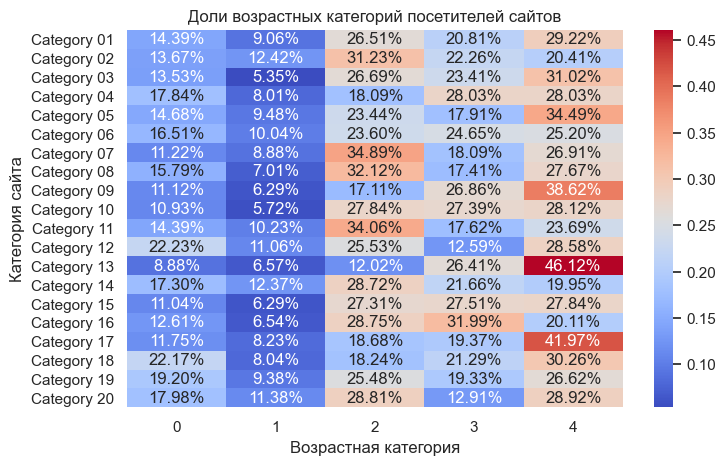

In [32]:
ct_row_norm = ct.div(ct.sum(axis=1), axis=0)
sns.heatmap(ct_row_norm, annot=True, fmt='.2%', cmap='coolwarm')

plt.title('Доли возрастных категорий посетителей сайтов')
plt.xlabel('Возрастная категория', fontsize=12)
plt.ylabel('Категория сайта', fontsize=12)
plt.show()

По долям возрастных категорий пользователей сайтов тоже можно наблюдать определенные тенденции. Тем не менее, с учетом дисбаланса классов в датасете информативность такой визуализации не слишком высока.

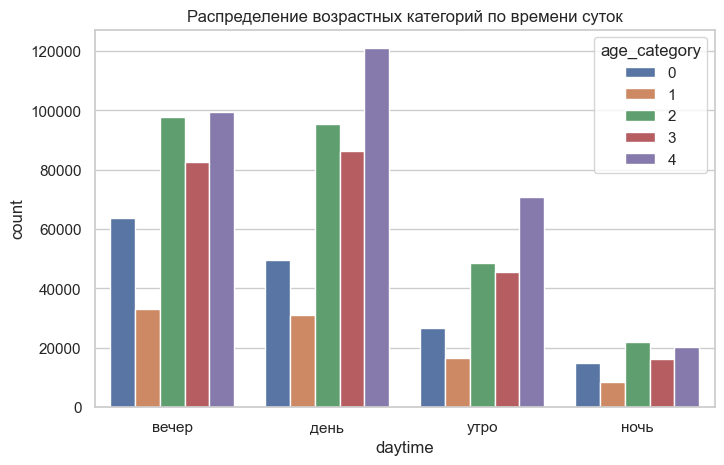

In [33]:
sns.countplot(data=df, x='daytime', hue='age_category')

plt.title('Распределение возрастных категорий по времени суток')
plt.show()

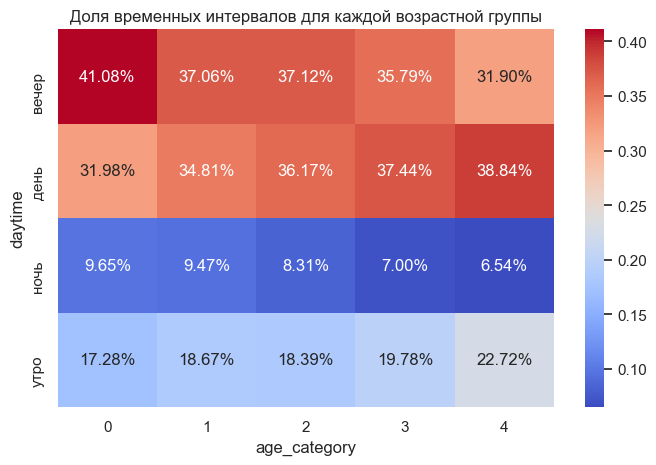

In [34]:
ct = pd.crosstab(df['daytime'], df['age_category'])
ct_norm = ct.div(ct.sum(axis=0), axis=1)
sns.heatmap(ct_norm, annot=True, fmt='.2%', cmap='coolwarm')
plt.title('Доля временных интервалов для каждой возрастной группы')
plt.show()

Паттерны активности по времени суток для каждой возрастной категории схожи. Можно отметить, что у категории 41-56+ по сравнению с остальными чаще проявляют активность утром и днем. Более молодые пользователи при этом более активны ночью и вечером нежели люди в возрасте.

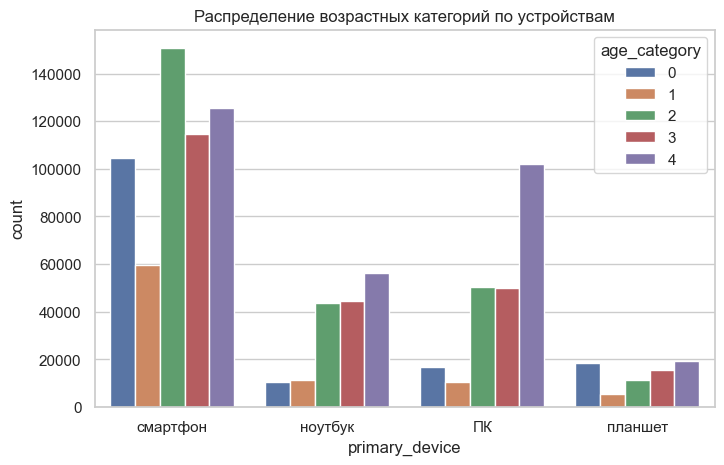

In [35]:
sns.countplot(data=df, x='primary_device', hue='age_category')

plt.title('Распределение возрастных категорий по устройствам')
plt.show()

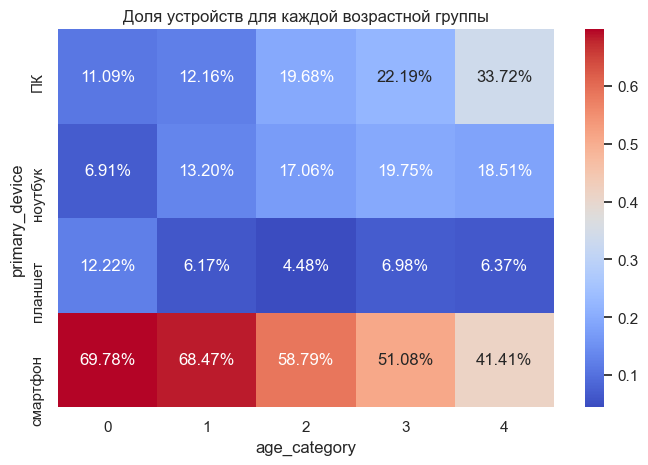

In [36]:
ct = pd.crosstab(df['primary_device'], df['age_category'])
ct_norm = ct.div(ct.sum(axis=0), axis=1)
sns.heatmap(ct_norm, annot=True, fmt='.2%', cmap='coolwarm')
plt.title('Доля устройств для каждой возрастной группы')
plt.show()

Большинство пользователей предпочитают смартфоны для выхода в Интернет, особенно молодые люди. У старших поколений при этом немного более выявлено использование ПК и ноутбуков. У молодых людей виден упор на более компактные мобильные средства, а у более взорслых сохраняется баланс между ноутбуками с ПК и смартфонами с планшетами.

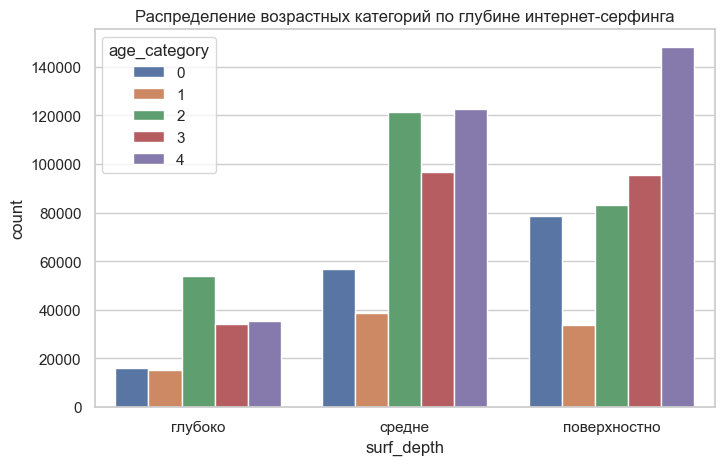

In [37]:
sns.countplot(data=df, x='surf_depth', hue='age_category')

plt.title('Распределение возрастных категорий по глубине интернет-серфинга')
plt.show()

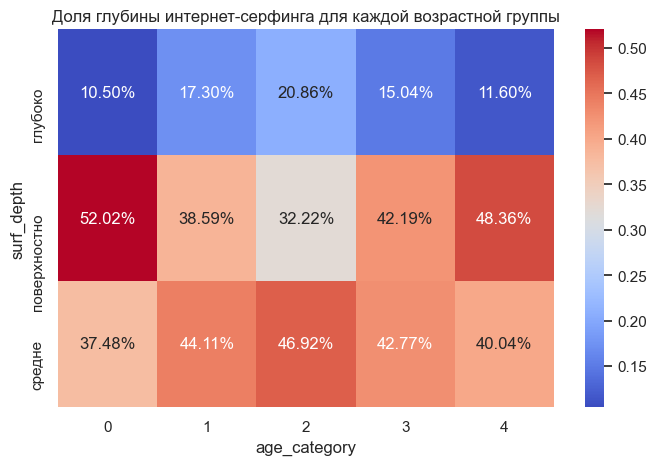

In [38]:
ct = pd.crosstab(df['surf_depth'], df['age_category'])
ct_norm = ct.div(ct.sum(axis=0), axis=1)
sns.heatmap(ct_norm, annot=True, fmt='.2%', cmap='coolwarm')
plt.title('Доля глубины интернет-серфинга для каждой возрастной группы')
plt.show()

Крайние возрастные категории (<18 и 56+ лет) по сравнению с остальными проводят в Интернете не так много времени во время одной сессии, они редко переходят на другие сайты и чаще остаются на одном. Люди в возрасте 18-55 посещают больше сайтов и в общем совершают больше переходов в другие источники.

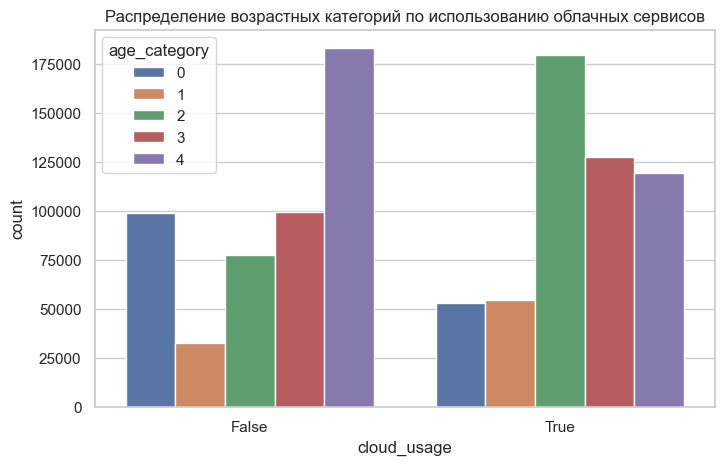

In [39]:
sns.countplot(data=df, x='cloud_usage', hue='age_category')

plt.title('Распределение возрастных категорий по использованию облачных сервисов')
plt.show()

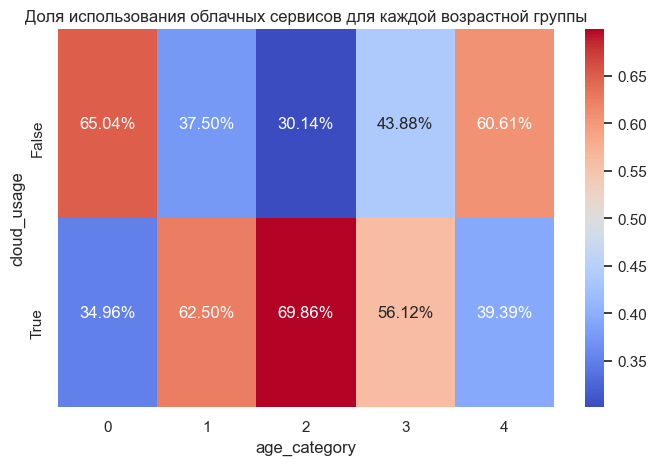

In [40]:
ct = pd.crosstab(df['cloud_usage'], df['age_category'])
ct_norm = ct.div(ct.sum(axis=0), axis=1)
sns.heatmap(ct_norm, annot=True, fmt='.2%', cmap='coolwarm')
plt.title('Доля использования облачных сервисов для каждой возрастной группы')
plt.show()

Здесь наблюдается схожая ситуация с глубиной интернет-серфинга. Облачными сервисами намного чаще пользуются люди 18-55 лет, поскольку используют их для учебы и работы.

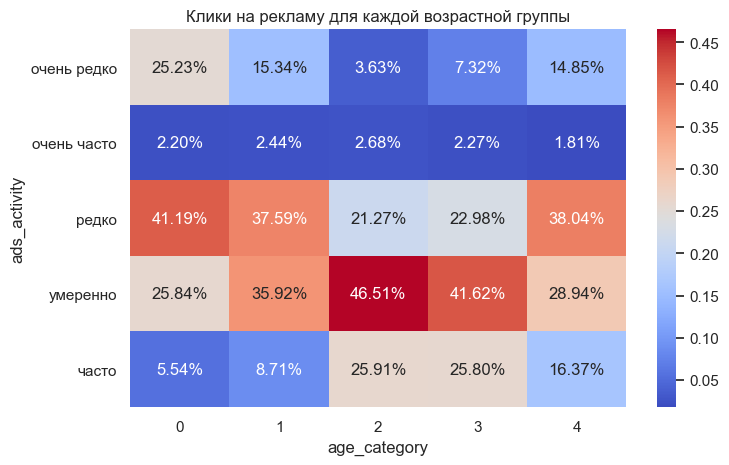

In [41]:
ct = pd.crosstab(df['ads_activity'], df['age_category'])
ct_norm = ct.div(ct.sum(axis=0), axis=1)
sns.heatmap(ct_norm, annot=True, fmt='.2%', cmap='coolwarm')
plt.title('Клики на рекламу для каждой возрастной группы')
plt.show()

Довольно часто реклама заинтересовывает пользователей 26-55 лет, уже активно работающих. Остальные категории, особенно молодые, кликают на рекламу реже. Это действительно указывает на необходимость персонализировать рекламу под определенные возрастные категории.

В общем, с каждым признаком выявлена определенная связь целевой переменной. Возраст пользователя влияет на действия в Интернете и их характер. 

### Корреляции

In [42]:
corr_df = df.drop(columns=['session_id', 'user_id']).copy()

phik_corr = corr_df.phik_matrix(interval_cols=[])

display(phik_corr.round(3))

,age_category,date,daytime,website_category,ads_activity,primary_device,surf_depth,cloud_usage
age_category,1.000,0.004,0.063,0.266,0.427,0.186,0.147,0.222
date,0.004,1.000,0.000,0.000,0.005,0.000,0.005,0.002
daytime,0.063,0.000,1.000,0.016,0.006,0.030,0.002,0.009
website_category,0.266,0.000,0.016,1.000,0.047,0.051,0.036,0.047
ads_activity,0.427,0.005,0.006,0.047,1.000,0.033,0.051,0.080
primary_device,0.186,0.000,0.030,0.051,0.033,1.000,0.019,0.021
surf_depth,0.147,0.005,0.002,0.036,0.051,0.019,1.000,0.022
cloud_usage,0.222,0.002,0.009,0.047,0.080,0.021,0.022,1.000


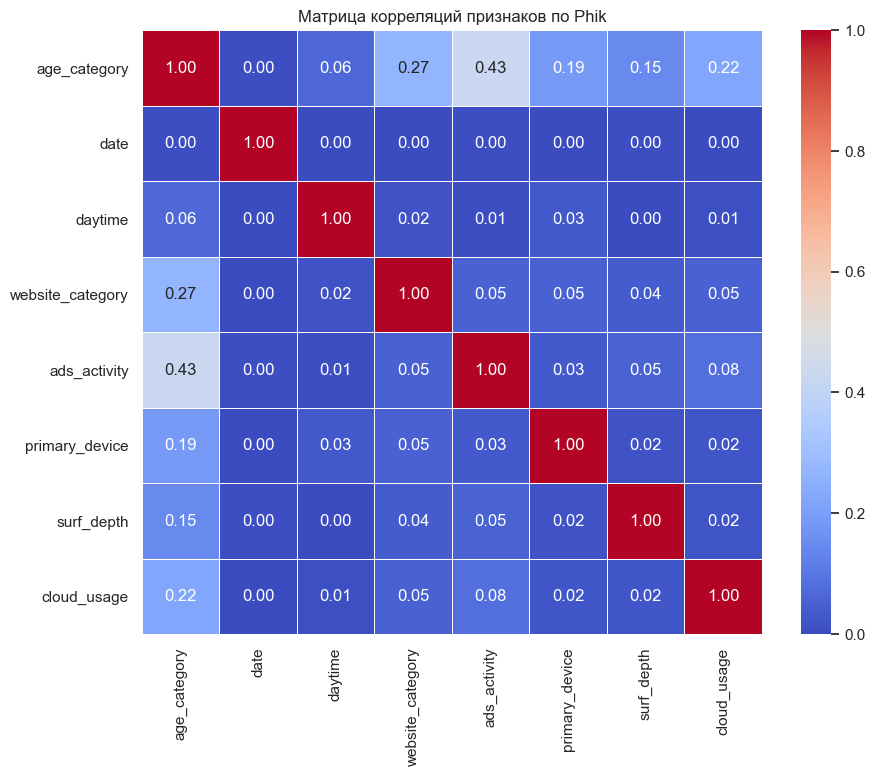

In [43]:
plt.figure(figsize=(10, 8))
heatmap = sns.heatmap(
    phik_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidth=0.5,
    vmin=0, vmax=1
)
plt.title('Матрица корреляций признаков по Phik')
plt.show()

In [44]:
target_corr = phik_corr['age_category'].drop('age_category').sort_values(ascending=False)
print(target_corr)

ads_activity        0.427099
website_category    0.266451
cloud_usage         0.221582
primary_device      0.185525
surf_depth          0.147473
daytime             0.062653
date                0.004240
Name: age_category, dtype: float64


Согласно матрице корреляций по Phik мультиколлинеарности между признаками не имеется. С целевой переменной наиболее связаны `ads_activity`, `website_category`, `cloud_usage`. Признаки `daytime` и `date` в исходном виде не несут особо полезной информации.

### Вывод

- **Базовая информация о датасете:**
Исходный сформированный датасет состоит из 10 столбцов, 1 123 383 записей. Признаки `user_id`, `session_id`, `date`, `daytime`, `website_category`, `ads_activity`, `primary_device`, `surf_depth`, `cloud_usage` имеют тип *object*. Целевая переменная `age_category` имеет тип *int64* (целочисленный).
- **Целевая переменная:**
Распределение целевой переменной по сессиям пользователей неравномерное. Зафиксированных сессий в Интернете у молодых пользователей меньше, чем у старших.
- **Изучение признаков:**
Признаки `user_id` и `session_id` являются уникальными идентификаторами. Остальные признаки имеют 2-20 уникальных значений.
- **Пропуски и дубликаты:**
Пропуски встречаются в признаках `ads_activity`, `primary_device`, `surf_depth`, `cloud_usage` с долями ~2-4%. Решено в будущем заменять большинство сигналом `unknown`, а `cloud_usage` - модой. Обнаружено и удалено 73 388 строк-дубликатов. В датасете осталось 1 049 995 строк.
- **Распределение признаков:**
Признаки имеют разное распределение значений по возрастным категориям, что указывает на их разнородные связи с целевой переменной. Каждая возрастная группа имеет определенный паттерн поведения в Интернете.
- **Корреляции:**
Мультиколлинеарности между признаками не присутствует. Особенно влияют на целевую переменную `ads_activity`, `website_category`, `cloud_usage`, а `daytime` и `date` очень слабо.

Для обучения модели определять возрастную группу конкретного пользователя в будущем необходимо будет реализовать функцию агрегации по всем сессиям данного человека на этапе создания признаков. Исходная предобработка данных и обучение базовых моделей будут реализованы на исходном датасете. Предобработка будет модифицирована после инжиниринга и отбора признаков.

## Предобработка данных

### Реализация трансформера для заполнения пропусков и кодировки признаков

In [45]:
cat_cols = [
    'date',
    'daytime',
    'website_category',
    'ads_activity',
    'primary_device',
    'surf_depth'
]

bool_cols = ['cloud_usage']

Признаки `user_id` и `session_id` пока что не будут полностью удалены из исходного датасета, поскольку понадобятся при инжниниринге признаков и агрегации данных по каждому пользователю.

In [46]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='constant', fill_value='unknown'),
        ),
        ("encoder", OneHotEncoder(handle_unknown="ignore"),
        )
    ]
)

bool_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy='most_frequent'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_pipeline, cat_cols),
        ('bool', bool_pipeline, bool_cols)
    ]
)
print(preprocessor)

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['date', 'daytime', 'website_category',
                                  'ads_activity', 'primary_device',
                                  'surf_depth']),
                                ('bool',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['cloud_usage'])])


### Разбиение данных на обучающую, тестовую и валидационную выборки

In [47]:
user_targets = (
    df[['user_id', 'age_category']]
    .drop_duplicates()
)

assert not user_targets['user_id'].duplicated().any()

train_users, test_users = train_test_split(
    user_targets,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=user_targets['age_category']
)

train_user_ids = set(train_users['user_id'])
test_user_ids = set(test_users['user_id'])

train_mask = df['user_id'].isin(train_user_ids)
test_mask = df['user_id'].isin(test_user_ids)

X_train = df.loc[train_mask].drop(
    columns=['age_category', 'user_id', 'session_id']
)

y_train = df.loc[train_mask, 'age_category']

X_test = df.loc[test_mask].drop(
    columns=['age_category', 'user_id', 'session_id']
)

y_test = df.loc[test_mask, 'age_category']

groups_train = df.loc[train_mask, 'user_id']

print('Train:', X_train.shape)
print('Test:', X_test.shape)

print('Train users:', len(train_user_ids))
print('Test users:', len(test_user_ids))

assert train_user_ids.isdisjoint(test_user_ids)

Train: (841250, 7)
Test: (208745, 7)
Train users: 4660
Test users: 1166


In [48]:
skf = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_user_targets = (
    df.loc[train_mask, ['user_id', 'age_category']]
    .drop_duplicates()
    .reset_index(drop=True)
)

cv_splits = []

for train_user_idx, val_user_idx in skf.split(
    train_user_targets['user_id'],
    train_user_targets['age_category']
):
    fold_train_users = set(
        train_user_targets.iloc[train_user_idx]['user_id']
    )

    fold_val_users = set(
        train_user_targets.iloc[val_user_idx]['user_id']
    )

    row_train_idx = np.where(
        groups_train.isin(fold_train_users)
    )[0]

    row_val_idx = np.where(
        groups_train.isin(fold_val_users)
    )[0]

    cv_splits.append(
        (row_train_idx, row_val_idx)
    )

In [49]:
for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):

    fold_train_users = set(groups_train.iloc[train_idx])
    fold_val_users = set(groups_train.iloc[val_idx])

    assert fold_train_users.isdisjoint(fold_val_users)

    print(
        f'Fold {fold}: '
        f'train users = {len(fold_train_users)}, '
        f'val users = {len(fold_val_users)}'
    )

Fold 1: train users = 3728, val users = 932
Fold 2: train users = 3728, val users = 932
Fold 3: train users = 3728, val users = 932
Fold 4: train users = 3728, val users = 932
Fold 5: train users = 3728, val users = 932


### Вывод

Реализован пайплайн для обработки изначально имеющихся признаков, которые являются категориальными. Пропуски заполняются значением `unknown`, затем происходит One-Hot кодировка категорий. Данные разбиты на обучающую и тестовую выборки в соотношении 80%/20% соответственно. Затем реализована кросс-валидация с 5 фолдами. Одни и те же пользователи не попадают в разные выборки.

## Обучение и оценка базовой модели

### Настройка метрик

In [50]:
scoring = {
    'f1_macro': make_scorer(
        f1_score,
        average='macro',
        zero_division=0
    ),
    'precision_macro': make_scorer(
        precision_score,
        average='macro',
        zero_division=0
    ),
    'recall_macro': make_scorer(
        recall_score,
        average='macro',
        zero_division=0
    )
}

### Обучение DummyClassifier

In [51]:
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

### Обучение базовой LogisticRegression

In [52]:
logreg_model = Pipeline([
    ('preprocessor', preprocessor),
    
    ('classifier', LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

### Обучение базовой SVC

In [53]:
svc_linear_model = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier', SVC(
        kernel='linear',
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

In [54]:
svc_rbf_model = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

### Сравнение моделей

In [55]:
def evaluate_model_cv(
    model,
    model_name,
    X,
    y,
    cv,
    scoring
):
    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    return {
        'model': model_name,

        'f1_macro_mean': scores['test_f1_macro'].mean(),
        'f1_macro_std': scores['test_f1_macro'].std(),

        'precision_macro_mean':
            scores['test_precision_macro'].mean(),

        'recall_macro_mean':
            scores['test_recall_macro'].mean()
    }

Обучение моделей по типу SVC на огромном количестве логов займет много времени. Применение и сравнение SVC-моделей лучше провести после агрегации данных по пользователям (создания признаков).

In [56]:
models = {
    'DummyClassifier': dummy_model,
    'LogisticRegression': logreg_model,
    #'SVC_linear': svc_linear_model,
    #'SVC_rbf': svc_rbf_model
}

cv_results = []

for model_name, model in models.items():

    print(f'Обучение {model_name}...')

    result = evaluate_model_cv(
        model=model,
        model_name=model_name,
        X=X_train,
        y=y_train,
        cv=cv_splits,
        scoring=scoring
    )

    cv_results.append(result)

Обучение DummyClassifier...
Обучение LogisticRegression...


In [57]:
cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        'f1_macro_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

display(cv_results_df.round(4))

,model,f1_macro_mean,f1_macro_std,precision_macro_mean,recall_macro_mean
0,LogisticRegression,0.3468,0.0136,0.3531,0.3611
1,DummyClassifier,0.1999,0.0010,0.2000,0.2000


### Вывод

Настроены метрики macro-усреднения для F1, precision и recall. Инициализированы базовые модели `DummyClassifier`, `LogisticRegression`, `SVC (линейная)`, `SVC (радиальная базисная функция)`. Пока что обучены и сопоставлены `DummyClassifier`, `LogisticRegression`, поскольку данные в исходном виде имеют слишком большое количество строк для обучения `SVC`. После создания новых признаков и группировки логов пользователей применить и данные будет рационально. По макро-усредненным метрикам обычная Логистическая Регрессия уже лучше Dummy, превосходя по метрикам качества примерно на +0.15.

## Создание и отбор признаков

### Feature engineering с агрегацией данных по пользователю

In [58]:
class UserFeatureExtractor(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.feature_columns_ = None

    @staticmethod
    def _mode(series):
        series = series.dropna()

        if series.empty:
            return np.nan

        return series.mode().iloc[0]

    @staticmethod
    def _clean_category_name(value):
        return (
            str(value)
            .lower()
            .replace(' ', '_')
            .replace('-', '_')
        )

    def _make_distribution_features(
        self,
        df,
        column,
        prefix
    ):
        shares = pd.crosstab(
            df['user_id'],
            df[column],
            normalize='index'
        )

        shares.columns = [
            f'share_{prefix}_{self._clean_category_name(value)}'
            for value in shares.columns
        ]

        #насклько пользователь сосредоточен на одной категории
        max_share = shares.max(axis=1)
        max_share.name = f'{prefix}_max_share'

        #энтропия распределения: высокая, значит активность распределена равномернее
        probabilities = shares.replace(0, np.nan)

        entropy = -(
            probabilities * np.log(probabilities)
        ).sum(axis=1)

        entropy = entropy.fillna(0)
        entropy.name = f'{prefix}_entropy'

        return pd.concat(
            [
                shares,
                max_share,
                entropy
            ],
            axis=1
        )

    def _create_features(self, X):

        df = X.copy()

        df['date'] = pd.to_datetime(df['date'])

        df['dayofweek'] = df['date'].dt.dayofweek
        df['is_weekend'] = (
            df['dayofweek']
            .isin([5, 6])
            .astype(int)
        )

        grouped = df.groupby('user_id')

        #основные характеристики пользователя
        features = grouped.agg(

            session_count=(
                'session_id',
                'nunique'
            ),

            active_days=(
                'date',
                'nunique'
            ),

            unique_website_categories=(
                'website_category',
                'nunique'
            ),

            weekend_share=(
                'is_weekend',
                'mean'
            ),

            primary_device=(
                'primary_device',
                self._mode
            ),

            surf_depth=(
                'surf_depth',
                self._mode
            ),

            ads_activity=(
                'ads_activity',
                self._mode
            ),

            cloud_usage=(
                'cloud_usage',
                self._mode
            ),

            dominant_website_category=(
                'website_category',
                self._mode
            ),

            dominant_daytime=(
                'daytime',
                self._mode
            ),

            dominant_dayofweek=(
                'dayofweek',
                self._mode
            ),

            first_activity_date=(
                'date',
                'min'
            ),

            last_activity_date=(
                'date',
                'max'
            )
        )

        #интенсивность активностии
        features['sessions_per_active_day'] = (
            features['session_count']
            / features['active_days']
        )

        #продолжительность периода активности пользователя
        features['activity_span_days'] = (
            features['last_activity_date']
            - features['first_activity_date']
        ).dt.days + 1

        #енасколько регулярно пользователь появлялся
        features['active_days_ratio'] = (
            features['active_days']
            / features['activity_span_days']
        )

        features = features.drop(
            columns=[
                'first_activity_date',
                'last_activity_date'
            ]
        )

        #распределение посещённых категорий сайтов
        website_features = self._make_distribution_features(
            df,
            'website_category',
            'website'
        )

        #по времени суток
        daytime_features = self._make_distribution_features(
            df,
            'daytime',
            'daytime'
        )

        #распределение по дням недели
        dayofweek_features = self._make_distribution_features(
            df,
            'dayofweek',
            'dayofweek'
        )

        features = pd.concat(
            [
                features,
                website_features,
                daytime_features,
                dayofweek_features
            ],
            axis=1
        )

        #категории должны иметь одинаковый тип для OHE
        categorical_features = [
            'primary_device',
            'surf_depth',
            'ads_activity',
            'cloud_usage',
            'dominant_website_category',
            'dominant_daytime',
            'dominant_dayofweek'
        ]

        for col in categorical_features:
            features[col] = features[col].apply(
                lambda x: str(x) if pd.notna(x) else np.nan
            )

        return features

    def fit(self, X, y=None):

        features = self._create_features(X)

        #запоминаем признаки, существовавшие в train
        self.feature_columns_ = features.columns.tolist()

        return self

    def transform(self, X):

        features = self._create_features(X)

        #В test могут отсутствовать отдельные категории, а также появиться новые
        features = features.reindex(
            columns=self.feature_columns_,
            fill_value=0
        )

        return features

### train/test уже на уровне пользователей

In [59]:
train_logs = (
    df.loc[train_mask]
    .drop(columns='age_category')
    .copy()
)

test_logs = (
    df.loc[test_mask]
    .drop(columns='age_category')
    .copy()
)

In [60]:
feature_extractor = UserFeatureExtractor()

X_train_users = feature_extractor.fit_transform(
    train_logs
)

X_test_users = feature_extractor.transform(
    test_logs
)

In [61]:
target_by_user = (
    user_targets
    .set_index('user_id')
    ['age_category']
)

y_train_users = target_by_user.reindex(
    X_train_users.index
)

y_test_users = target_by_user.reindex(
    X_test_users.index
)

In [62]:
print('Train:', X_train_users.shape)
print('Test:', X_test_users.shape)

print()
print('Пропуски target train:', y_train_users.isna().sum())
print('Пропуски target test:', y_test_users.isna().sum())

assert len(X_train_users) == len(y_train_users)
assert len(X_test_users) == len(y_test_users)

assert X_train_users.index.is_unique
assert X_test_users.index.is_unique

assert set(X_train_users.index).isdisjoint(
    set(X_test_users.index)
)

Train: (4660, 51)
Test: (1166, 51)

Пропуски target train: 0
Пропуски target test: 0


### Новый preprocessing

In [63]:
user_cat_cols = [
    'primary_device',
    'surf_depth',
    'ads_activity',
    'cloud_usage',
    'dominant_website_category',
    'dominant_daytime',
    'dominant_dayofweek'
]

In [64]:
user_num_cols = [
    col
    for col in X_train_users.columns
    if col not in user_cat_cols
]

print('Категориальных:', len(user_cat_cols))
print('Числовых:', len(user_num_cols))

Категориальных: 7
Числовых: 44


In [65]:
numeric_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='constant',
            fill_value='unknown'
        )
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

user_preprocessor = ColumnTransformer([
    (
        'numeric',
        numeric_pipeline,
        user_num_cols
    ),
    (
        'categorical',
        categorical_pipeline,
        user_cat_cols
    )
])

### Обучение и сравнение базовых моделей на данных пользователей

In [66]:
user_cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [67]:
logreg_user_model = Pipeline([
    (
        'preprocessor',
        user_preprocessor
    ),
    (
        'classifier',
        LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            max_iter=2000,
            C=1.0,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    )
])

In [68]:
svc_linear_user_model = Pipeline([
    (
        'preprocessor',
        user_preprocessor
    ),
    (
        'classifier',
        SVC(
            kernel='linear',
            C=1.0,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    )
])

In [69]:
svc_rbf_user_model = Pipeline([
    (
        'preprocessor',
        user_preprocessor
    ),
    (
        'classifier',
        SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    )
])

In [70]:
dummy_user_model = DummyClassifier(
    strategy='stratified',
    random_state=RANDOM_STATE
)

In [71]:
models_after_fe = {
    'DummyClassifier': dummy_user_model,
    'LogisticRegression_FE': logreg_user_model,
    'SVC_linear_FE': svc_linear_user_model,
    'SVC_rbf_FE': svc_rbf_user_model
}

fe_results = []

for model_name, model in models_after_fe.items():

    print(f'Обучение {model_name}...')

    result = evaluate_model_cv(
        model=model,
        model_name=model_name,
        X=X_train_users,
        y=y_train_users,
        cv=user_cv,
        scoring=scoring
    )

    fe_results.append(result)

Обучение DummyClassifier...
Обучение LogisticRegression_FE...
Обучение SVC_linear_FE...
Обучение SVC_rbf_FE...


In [72]:
fe_results_df = (
    pd.DataFrame(fe_results)
    .sort_values(
        'f1_macro_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

display(fe_results_df.round(4))

,model,f1_macro_mean,f1_macro_std,precision_macro_mean,recall_macro_mean
0,SVC_rbf_FE,0.8783,0.0048,0.8751,0.8830
1,LogisticRegression_FE,0.8209,0.0091,0.8155,0.8313
2,SVC_linear_FE,0.8130,0.0085,0.8072,0.8243
3,DummyClassifier,0.1991,0.0108,0.1993,0.1990


### Отбор признаков

In [73]:
feature_selector = SelectFromModel(
    estimator=LogisticRegression(
        penalty='l1',
        solver='liblinear',
        multi_class='ovr',
        C=0.1,
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    threshold='mean'
)

In [74]:
logreg_selected_model = Pipeline([
    (
        'preprocessor',
        user_preprocessor
    ),

    (
        'feature_selection',
        SelectFromModel(
            LogisticRegression(
                penalty='l1',
                solver='liblinear',
                multi_class='ovr',
                C=0.1,
                class_weight='balanced',
                max_iter=2000,
                random_state=RANDOM_STATE
            ),
            threshold='mean'
        )
    ),

    (
        'classifier',
        LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            C=1.0,
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )
])

In [75]:
svc_linear_selected_model = Pipeline([
    (
        'preprocessor',
        user_preprocessor
    ),

    (
        'feature_selection',
        SelectFromModel(
            LogisticRegression(
                penalty='l1',
                solver='liblinear',
                multi_class='ovr',
                C=0.1,
                class_weight='balanced',
                max_iter=2000,
                random_state=RANDOM_STATE
            ),
            threshold='mean'
        )
    ),

    (
        'classifier',
        SVC(
            kernel='linear',
            C=1.0,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    )
])

In [76]:
svc_rbf_selected_model = Pipeline([
    (
        'preprocessor',
        user_preprocessor
    ),

    (
        'feature_selection',
        SelectFromModel(
            LogisticRegression(
                penalty='l1',
                solver='liblinear',
                multi_class='ovr',
                C=0.1,
                class_weight='balanced',
                max_iter=2000,
                random_state=RANDOM_STATE
            ),
            threshold='mean'
        )
    ),

    (
        'classifier',
        SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    )
])

In [77]:
selection_models = {
    'LogReg_all_features': logreg_user_model,
    'LogReg_selected': logreg_selected_model,

    'SVC_linear_all_features': svc_linear_user_model,
    'SVC_linear_selected': svc_linear_selected_model,

    'SVC_rbf_all_features': svc_rbf_user_model,
    'SVC_rbf_selected': svc_rbf_selected_model
}

selection_results = []

for model_name, model in selection_models.items():

    print(f'Обучение {model_name}...')

    result = evaluate_model_cv(
        model=model,
        model_name=model_name,
        X=X_train_users,
        y=y_train_users,
        cv=user_cv,
        scoring=scoring
    )

    selection_results.append(result)

Обучение LogReg_all_features...
Обучение LogReg_selected...
Обучение SVC_linear_all_features...
Обучение SVC_linear_selected...
Обучение SVC_rbf_all_features...
Обучение SVC_rbf_selected...


In [78]:
selection_results_df = (
    pd.DataFrame(selection_results)
    .sort_values(
        'f1_macro_mean',
        ascending=False
    )
    .reset_index(drop=True)
)

display(selection_results_df.round(4))

,model,f1_macro_mean,f1_macro_std,precision_macro_mean,recall_macro_mean
0,SVC_rbf_selected,0.8980,0.0044,0.8936,0.9041
1,SVC_rbf_all_features,0.8783,0.0048,0.8751,0.8830
2,LogReg_selected,0.8249,0.0055,0.8185,0.8361
3,SVC_linear_selected,0.8234,0.0075,0.8167,0.8347
4,LogReg_all_features,0.8209,0.0091,0.8155,0.8313
5,SVC_linear_all_features,0.8130,0.0085,0.8072,0.8243


### Отобранные признаки

In [79]:
logreg_selected_model.fit(
    X_train_users,
    y_train_users
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['session_count',
                                                   'active_days',
                                                   'unique_website_categories',
                                                   'weekend_share',
                                                   'sessions_per_active_day',
                                                   'activity_span_days',
                                                   'active_days_ratio',
                                                   'shar

In [80]:
fitted_preprocessor = (
    logreg_selected_model
    .named_steps['preprocessor']
)

fitted_ohe = (
    fitted_preprocessor
    .named_transformers_['categorical']
    .named_steps['encoder']
)

In [81]:
categorical_feature_names = (
    fitted_ohe.get_feature_names(
        user_cat_cols
    )
)

In [82]:
all_feature_names = np.concatenate([
    np.array(user_num_cols),
    categorical_feature_names
])

In [83]:
selection_mask = (
    logreg_selected_model
    .named_steps['feature_selection']
    .get_support()
)

In [84]:
selected_feature_names = (
    all_feature_names[selection_mask]
)

print(
    'Всего признаков после preprocessing:',
    len(all_feature_names)
)

print(
    'Отобрано:',
    len(selected_feature_names)
)

display(
    pd.DataFrame({
        'selected_feature':
            selected_feature_names
    })
)

Всего признаков после preprocessing: 92
Отобрано: 33


,selected_feature
0,share_website_category_02
1,share_website_category_03
2,share_website_category_04
3,share_website_category_05
4,share_website_category_06
5,share_website_category_07
6,share_website_category_08
7,share_website_category_09
8,share_website_category_10
9,share_website_category_11


### Вывод

- **Feature engineering и новый preprocessing:** Теперь признаки из логов агрегируются для каждого пользователя отдельно, создавая его портрет. Создается множество новых признаков на основе имеющихся. К примеру, признаки предпочтений пользователя по категориям сайтов, энтропия (распределение активности по сайтам), активные дни недели, интенсивность активности и т.п. Разделение на выборки теперь явно происходит на уровне пользователей. Старый препроцессор модифицирован и теперь поддерживает новые признаки.

- **Сравнение базовых моделей с новым пайплайном:** После изменения пайплайна предобработки и создания признаков метрики базовых моделей значительно выросли (DummyClassifier это не касается, он не пользуется предобработкой). Использование `SVC` стало рациональным на меньшем наборе строк. `Макро-усредненные F1-метрики` у моделей теперь следующие: `SVC(rbf)` - `0.8783`, `LogisticRegression` - `0.8209`, `SVC(linear)` - `0.8130`. 

- **Отбор признаков:** Для отбора признаков использован model-based selection через L1 LogisticRegression. L1-регуляризация склонна обнулять коэффициенты малоинформативных признаков. SelectFromModel затем удаляет признаки с малой важностью. После отбора признаков топовая модель `SVC_rbf_selected` имеет усредненные макро-метрики: `F1 = 0.8980`, `Precision = 0.8936`, `Recall = 0.9041`. Модель хорошо распознает классы. Большинство отобранных признаков относятся к долям категорий посещаемых вебсайтов пользователем, далее идут признаки времени, взаимодействия с рекламой и т.д.

## Подбор гиперпараметров моделей

### Сетки параметров

In [85]:
logreg_param_grid = {
    'classifier__C': [
        0.01,
        0.03,
        0.1,
        0.3,
        1,
        3,
        10,
        30
    ],

    'classifier__class_weight': [
        None,
        'balanced'
    ]
}

In [86]:
svc_linear_param_grid = {
    'classifier__C': [
        0.01,
        0.03,
        0.1,
        0.3,
        1,
        3,
        10,
        30
    ],

    'classifier__class_weight': [
        None,
        'balanced'
    ]
}

In [87]:
svc_rbf_param_grid = {
    'classifier__C': [
        0.1,
        0.3,
        1,
        3,
        10,
        30
    ],

    'classifier__gamma': [
        'scale',
        0.003,
        0.01,
        0.03,
        0.1
    ],

    'classifier__class_weight': [
        None,
        'balanced'
    ]
}

### GridSearchCV для моделей

In [88]:
def run_grid_search(
    model,
    param_grid,
    X,
    y,
    cv,
    scoring
):
    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,

        scoring=scoring,
        refit='f1_macro',

        cv=cv,

        n_jobs=-1,
        verbose=1,

        return_train_score=True
    )

    search.fit(X, y)

    return search

**!Далее GridSearchCV закомменчены для экономии времени при перезапуске блокнота, результаты в виде текста/изображений!**

### Подбор гиперпараметров для LogisticRegression

Лучшие параметры: {'classifier__C': 1, 'classifier__class_weight': None}
Лучший macro-F1: 0.8265

### Подбор гиперпараметров для SVC(linear)

Лучшие параметры: {'classifier__C': 10, 'classifier__class_weight': None}
Лучший macro-F1: 0.8375

### Подбор гиперпараметров для SVC(rbf)

Лучшие параметры: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale'}
Лучший macro-F1: 0.898

### Сравнение моделей после подбора гиперпараметров

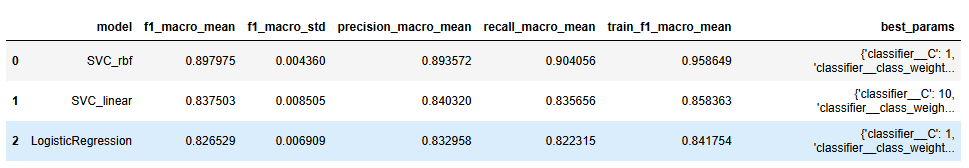

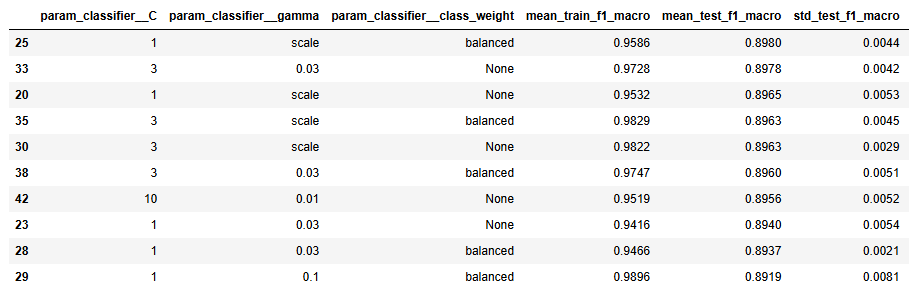 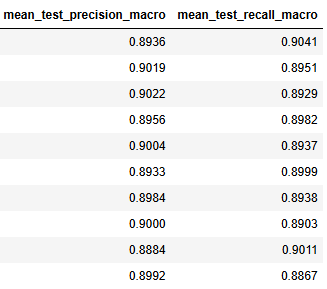

GridSearchCV не улучшил качество модели, поскольку подходящие параметры уже имеются в модели `svc_rbf_selected_model`, он подтвердил, что они действительно являются лучшими.

### Попытка улучшения SVC(rbf)

In [89]:
svc_rbf_full_param_grid = {
    # SelectFromModel
    'feature_selection__estimator__C': [
        0.03,
        0.1,
        0.3,
        1.0
    ],

    'feature_selection__threshold': [
        'median',
        'mean'
    ],

    # RBF-SVC
    'classifier__C': [
        0.3,
        1,
        3
    ],

    'classifier__gamma': [
        'scale',
        0.003,
        0.01,
        0.03
    ],

    # Уже установили, что balanced лучше
    'classifier__class_weight': [
        'balanced'
    ]
}

Лучшие параметры:
{'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__gamma': 'scale', 'feature_selection__estimator__C': 0.3, 'feature_selection__threshold': 'median'}
Лучший macro-F1: 0.9017

In [90]:
best_model_final = Pipeline([
    (
        'preprocessor',
        user_preprocessor
    ),

    (
        'feature_selection',
        SelectFromModel(
            LogisticRegression(
                penalty='l1',
                solver='liblinear',
                multi_class='ovr',
                C=0.3,
                class_weight='balanced',
                max_iter=2000,
                random_state=RANDOM_STATE
            ),
            threshold='median'
        )
    ),

    (
        'classifier',
        SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    )
])

best_model_final.fit(X_train_users, y_train_users)


y_test_pred = best_model_final.predict(
    X_test_users
)


In [91]:
test_f1 = f1_score(
    y_test_users,
    y_test_pred,
    average='macro'
)

test_precision = precision_score(
    y_test_users,
    y_test_pred,
    average='macro',
    zero_division=0
)

test_recall = recall_score(
    y_test_users,
    y_test_pred,
    average='macro',
    zero_division=0
)

print(f'Test macro-F1:        {test_f1:.4f}')
print(f'Test macro-Precision: {test_precision:.4f}')
print(f'Test macro-Recall:    {test_recall:.4f}')

Test macro-F1:        0.8972
Test macro-Precision: 0.8906
Test macro-Recall:    0.9063


In [92]:
print(
    classification_report(
        y_test_users,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.8920    0.9181    0.9049       171
           1     0.7521    0.8835    0.8125       103
           2     0.9078    0.8889    0.8982       288
           3     0.9496    0.9004    0.9243       251
           4     0.9513    0.9405    0.9459       353

    accuracy                         0.9108      1166
   macro avg     0.8906    0.9063    0.8972      1166
weighted avg     0.9139    0.9108    0.9117      1166



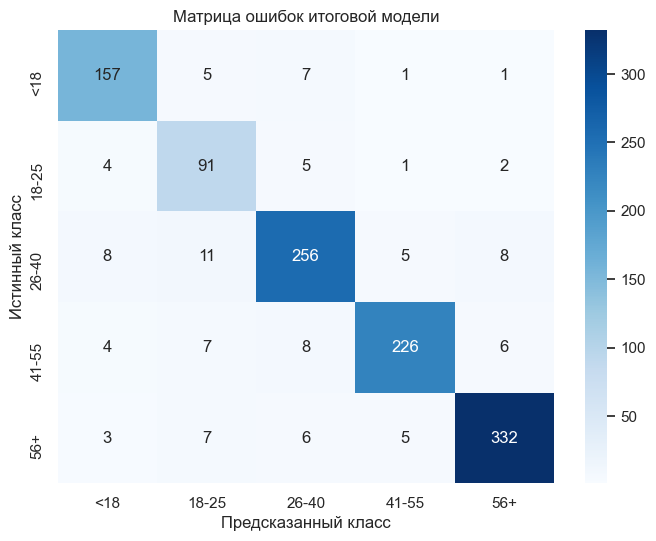

In [93]:
cm = confusion_matrix(
    y_test_users,
    y_test_pred
)

cm_df = pd.DataFrame(
    cm,
    index=['<18', '18-25', '26-40', '41-55', '56+'],
    columns=['<18', '18-25', '26-40', '41-55', '56+']
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок итоговой модели')

plt.show()

### Вывод

После подбора гиперпараметров с помощью GridSearchCV была выявлена наилучшая модель SVC с нелинейным ядром `rbf` и параметрами `C=1.0`, `gamma='scale'`, `class_weight='balanced'` и измененными параметрами `feature_selection` `C=0.3`, `threshold='median'`. Основная макро-усредненная метрика F1 на тестовой выборке составила `0.8972`. Близость результатов кросс-валидации и тестовой выборки свидетельствует об устойчивости полученного качества на ранее не использовавшихся при обучении данных. Требование к значению macro-F1 не менее 0.75 выполнено как на кросс-валидации, так и на тестовой выборке.

## Подготовка артефактов модели для внедрения

### Создание директории для артефактов модели и сохранение основных элементов

In [94]:
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [95]:
joblib.dump(
    feature_extractor,
    ARTIFACTS_DIR / 'user_feature_extractor.joblib'
)

['artifacts\\user_feature_extractor.joblib']

In [96]:
joblib.dump(
    best_model_final,
    ARTIFACTS_DIR / 'age_classifier_pipeline.joblib'
)

['artifacts\\age_classifier_pipeline.joblib']

In [97]:
metadata = {
    'model_name': 'SVC_RBF',

    'sklearn_version': sklearn.__version__,

    'target': 'age_category',

    'age_categories': {
        '0': '<18',
        '1': '18-25',
        '2': '26-40',
        '3': '41-55',
        '4': '56+'
    },

    'best_params': {
        'classifier__C': 1.0,
        'classifier__gamma': 'scale',
        'classifier__class_weight': 'balanced',

        'feature_selection__estimator__C': 0.3,
        'feature_selection__threshold': 'median'
    },

    'cv_macro_f1': 0.9017,

    'test_macro_f1': 0.8972,
    'test_macro_precision': 0.8906,
    'test_macro_recall': 0.9063,

    'n_user_features': int(X_train_users.shape[1]),

    'n_selected_features': int(
        best_model_final
        .named_steps['feature_selection']
        .get_support()
        .sum()
    )
}

with open(
    ARTIFACTS_DIR / 'metadata.json',
    'w',
    encoding='utf-8'
) as file:

    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=4
    )

In [98]:
%%writefile feature_engineering.py

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin


class UserFeatureExtractor(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.feature_columns_ = None

    @staticmethod
    def _mode(series):
        series = series.dropna()

        if series.empty:
            return np.nan

        return series.mode().iloc[0]

    @staticmethod
    def _clean_category_name(value):
        return (
            str(value)
            .lower()
            .replace(' ', '_')
            .replace('-', '_')
        )

    def _make_distribution_features(
        self,
        df,
        column,
        prefix
    ):
        shares = pd.crosstab(
            df['user_id'],
            df[column],
            normalize='index'
        )

        shares.columns = [
            f'share_{prefix}_{self._clean_category_name(value)}'
            for value in shares.columns
        ]

        max_share = shares.max(axis=1)
        max_share.name = f'{prefix}_max_share'

        probabilities = shares.replace(0, np.nan)

        entropy = -(
            probabilities * np.log(probabilities)
        ).sum(axis=1)

        entropy = entropy.fillna(0)
        entropy.name = f'{prefix}_entropy'

        return pd.concat(
            [shares, max_share, entropy],
            axis=1
        )

    def _create_features(self, X):

        df = X.copy()

        df['date'] = pd.to_datetime(df['date'])

        df['dayofweek'] = df['date'].dt.dayofweek
        df['is_weekend'] = (
            df['dayofweek']
            .isin([5, 6])
            .astype(int)
        )

        grouped = df.groupby('user_id')

        features = grouped.agg(
            session_count=('session_id', 'nunique'),
            active_days=('date', 'nunique'),
            unique_website_categories=(
                'website_category',
                'nunique'
            ),
            weekend_share=('is_weekend', 'mean'),
            primary_device=('primary_device', self._mode),
            surf_depth=('surf_depth', self._mode),
            ads_activity=('ads_activity', self._mode),
            cloud_usage=('cloud_usage', self._mode),
            dominant_website_category=(
                'website_category',
                self._mode
            ),
            dominant_daytime=('daytime', self._mode),
            dominant_dayofweek=('dayofweek', self._mode),
            first_activity_date=('date', 'min'),
            last_activity_date=('date', 'max')
        )

        features['sessions_per_active_day'] = (
            features['session_count']
            / features['active_days']
        )

        features['activity_span_days'] = (
            features['last_activity_date']
            - features['first_activity_date']
        ).dt.days + 1

        features['active_days_ratio'] = (
            features['active_days']
            / features['activity_span_days']
        )

        features = features.drop(
            columns=[
                'first_activity_date',
                'last_activity_date'
            ]
        )

        website_features = self._make_distribution_features(
            df,
            'website_category',
            'website'
        )

        daytime_features = self._make_distribution_features(
            df,
            'daytime',
            'daytime'
        )

        dayofweek_features = self._make_distribution_features(
            df,
            'dayofweek',
            'dayofweek'
        )

        features = pd.concat(
            [
                features,
                website_features,
                daytime_features,
                dayofweek_features
            ],
            axis=1
        )

        categorical_features = [
            'primary_device',
            'surf_depth',
            'ads_activity',
            'cloud_usage',
            'dominant_website_category',
            'dominant_daytime',
            'dominant_dayofweek'
        ]

        for col in categorical_features:
            features[col] = features[col].apply(
                lambda x: str(x) if pd.notna(x) else np.nan
            )

        return features

    def fit(self, X, y=None):

        features = self._create_features(X)

        self.feature_columns_ = features.columns.tolist()

        return self

    def transform(self, X):

        features = self._create_features(X)

        features = features.reindex(
            columns=self.feature_columns_,
            fill_value=0
        )

        return features

Writing feature_engineering.py


### Загрузка модели и проверка работоспособности

In [99]:
pred_before_save = best_model_final.predict(
    X_test_users
)

In [100]:
loaded_feature_extractor = joblib.load(
    ARTIFACTS_DIR / 'user_feature_extractor.joblib'
)

loaded_model = joblib.load(
    ARTIFACTS_DIR / 'age_classifier_pipeline.joblib'
)

In [101]:
X_test_users_loaded = (
    loaded_feature_extractor.transform(
        test_logs
    )
)

In [102]:
pred_after_load = loaded_model.predict(
    X_test_users_loaded
)

In [103]:
pd.testing.assert_frame_equal(
    X_test_users,
    X_test_users_loaded
)

print(
    'OK: признаки до и после загрузки '
    'feature extractor совпадают'
)

OK: признаки до и после загрузки feature extractor совпадают


In [104]:
assert np.array_equal(
    pred_before_save,
    pred_after_load
)

print(
    'OK: предсказания модели '
    'до и после сохранения совпадают'
)

OK: предсказания модели до и после сохранения совпадают


In [105]:
loaded_test_f1 = f1_score(
    y_test_users,
    pred_after_load,
    average='macro'
)

print(
    f'Macro-F1 загруженной модели: '
    f'{loaded_test_f1:.4f}'
)

Macro-F1 загруженной модели: 0.8972


## Выводы о результатах работы

В рамках проекта была разработана модель многоклассовой классификации пользователей интернет-сервисов по пяти возрастным категориям на основе данных об их активности в сети.

На начальном этапе была построена базовая модель на исходных данных. `LogisticRegression` показала значение `macro-F1 около 0.35`, что заметно превышало качество `DummyClassifier`, однако не соответствовало требованию заказчика к значению `F1 не менее 0.75`. Это показало, что исходное представление логов недостаточно хорошо описывает поведение конкретного пользователя и требует дополнительной обработки.

Основное улучшение качества было достигнуто за счёт перехода от отдельных записей о посещениях к пользовательскому уровню представления данных. Для каждого пользователя были рассчитаны признаки, характеризующие интенсивность и регулярность активности, распределение посещений по категориям сайтов, времени суток и дням недели, разнообразие интересов, взаимодействие с рекламой, используемые устройства и другие особенности поведения. В результате одна строка итогового признакового пространства стала соответствовать одному уникальному пользователю.

После создания новых признаков качество всех рассмотренных моделей существенно увеличилось. Наиболее высокие результаты показала модель `SVC с RBF-ядром`. Дополнительный отбор признаков с помощью SelectFromModel на основе L1-регуляризованной LogisticRegression позволил повысить значение `macro-F1` модели SVC с RBF-ядром с `0.8783 до 0.8980`. При этом из 92 признаков после этапа предобработки была сохранена наиболее информативная их часть.

На этапе подбора гиперпараметров были исследованы различные конфигурации моделей. Наилучший результат показал пайплайн с SVC с RBF-ядром и предварительным отбором признаков. Для итоговой модели были выбраны параметры `C=1.0, gamma='scale' и class_weight='balanced'`. Для LogisticRegression, используемой внутри SelectFromModel, оптимальным значнием параметра регуляризации стало `C=0.3`, а `порог отбора признаков - median`. Значение macro-F1 итоговой модели на кросс-валидации составило 0.9017.

На отложенной тестовой выборке итоговая модель получила `macro-F1`, равную `0.8972`, `macro-precision` - `0.8906` и `macro-recall` - `0.9063`. Близость результатов на кросс-валидации и тестовой выборке указывает на устойчивость модели и отсутствие выраженного переобучения. `Для пользователей младше 18 лет значение recall составило около 0.92`, что особенно важно с учётом задачи снижения риска показа несовершеннолетним рекламы, не соответствующей их возрастной категории.

При формировании обучающей и тестовой выборок разделение выполнялось по уникальным пользователям, благодаря чему данные одного пользователя не могли одновременно попасть в обе выборки. Все операции предобработки и отбора признаков выполнялись внутри пайплайна и обучались только на тренировочных данных соответствующих фолдов, что позволило избежать утечки данных при оценке качества.

Для дальнейшего использования модели предусмотрены отдельный компонент формирования пользовательских признаков из исходных логов и итоговый sklearn-пайплайн, содержащий предобработку данных, отбор признаков и классификатор. Такое представление позволяет воспроизводить полный процесс получения прогноза для новых данных и ипсользовать обученную модель вне исследовательского ноутбука.

Таким образом, поставленная задача решена: разработанная модель превышает установленный заказчиком порог macro-F1, равный 0.75, как на кросс-валидации, так и на независимой тестовой выборке. Полученный результат позволяет рекомендовать модель для дальнейшей интеграции и тестирования в составе системы возрастного таргетинга рекламной сети.